<ipython-input-1-83923a9c68bc>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=alert_counts.index, y=alert_counts.values, palette='coolwarm')


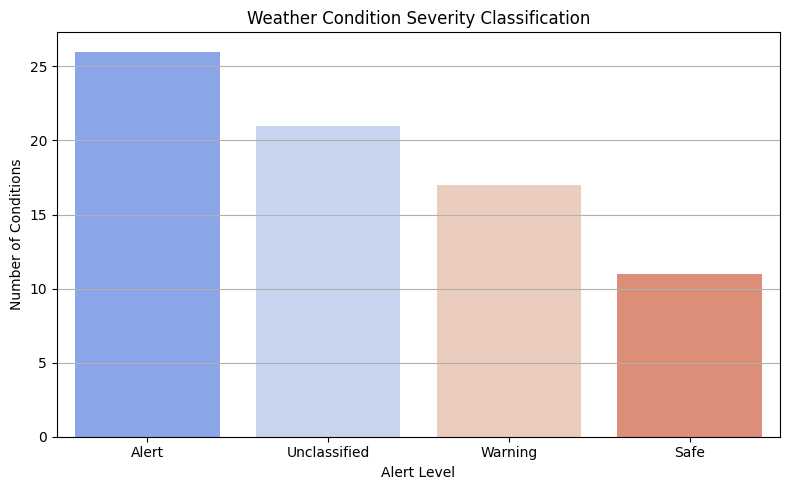

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("Weather.csv")

# Classify alert levels based on keywords
def classify_alert(description):
    desc_lower = str(description).lower()
    if any(word in desc_lower for word in ['zware', 'onweer', 'hagel', 'stroomrafelingen', 'verstopte']):
        return 'Alert'
    elif any(word in desc_lower for word in ['matige', 'afwisselend', 'buien', 'mist', 'heiige']):
        return 'Warning'
    elif any(word in desc_lower for word in ['licht', 'heldere', 'dauw', 'nevel']):
        return 'Safe'
    else:
        return 'Unclassified'

df['Alert_Level'] = df['Description'].apply(classify_alert)

# Count alert levels
alert_counts = df['Alert_Level'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=alert_counts.index, y=alert_counts.values, palette='coolwarm')
plt.title('Weather Condition Severity Classification')
plt.xlabel('Alert Level')
plt.ylabel('Number of Conditions')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import folium
from folium import Map
from IPython.display import display, HTML

# Load your data
df = pd.read_csv("Geodata.csv")

# Drop rows with missing coordinates
df = df.dropna(subset=['DecLatitude', 'DecLongitude'])

# Define alert logic
def classify_geofence(row):
    if pd.isna(row['Ocean']):
        return 'Unknown Zone'
    elif any(sea in str(row['Ocean']) for sea in ['Indian Ocean', 'Bay of Bengal']):
        return 'Risk Zone'
    elif row['DecLatitude'] < -30 or row['DecLatitude'] > 60:
        return 'Extreme Latitude'
    else:
        return 'Safe'

df['AlertType'] = df.apply(classify_geofence, axis=1)

# Initialize map
m = folium.Map(location=[df['DecLatitude'].mean(), df['DecLongitude'].mean()], zoom_start=2)

# Color mapping
colors = {'Safe': 'green', 'Risk Zone': 'orange', 'Extreme Latitude': 'red', 'Unknown Zone': 'gray'}

# Add markers
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['DecLatitude'], row['DecLongitude']],
        radius=5,
        color=colors.get(row['AlertType'], 'blue'),
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['Place']} - {row['AlertType']}"
    ).add_to(m)

# Display in Colab
m.save("map.html")
display(HTML("map.html"))  # or:
m  # Simply outputting the map object also works
